## Filled contour styles

This notebook shows how to control colour levels and encapsulate your
styling choices in a reusable `Style` object.

In [1]:
import earthkit.data as ekd

import earthkit.plots as ekp

data = ekd.from_source("sample", "era5-2t-msl-1985122512.grib").to_fieldlist()
pressure = data.sel({"parameter.variable": "msl"})
temperature = data.sel({"parameter.variable": "2t"})

era5-2t-msl-1985122512.grib:   0%|          | 0.00/3.96M [00:00<?, ?B/s]

### Specifying levels

As with contour lines, you can pass levels as a list or range:

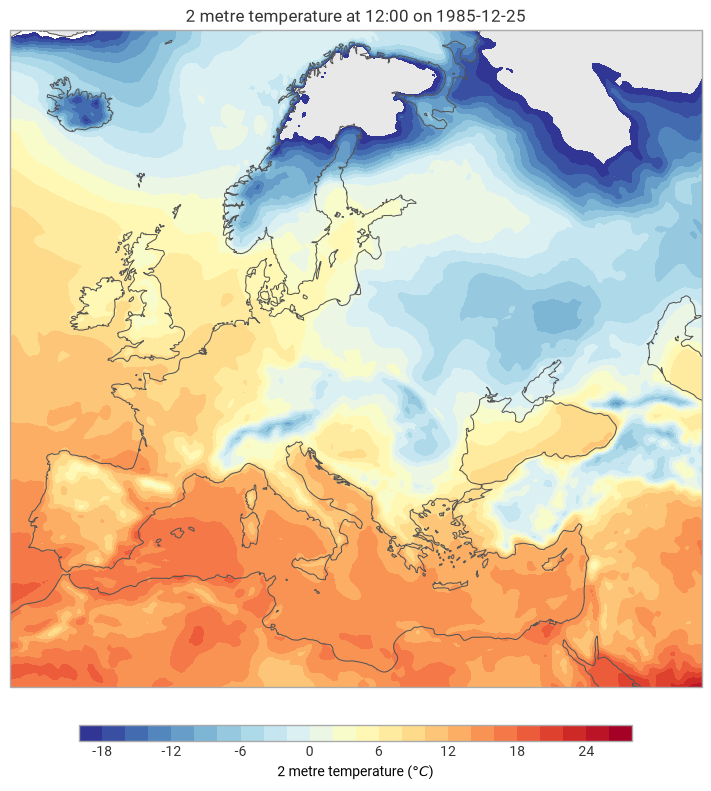

In [2]:
chart = ekp.Map(domain="Europe")
chart.contourf(
    temperature,
    units="celsius",
    levels=range(-20, 30, 2),
    colors="RdYlBu_r",
)
chart.legend()
chart.land()
chart.coastlines()
chart.title()
chart.show()

Or as a dict with `step` and `reference` keys:

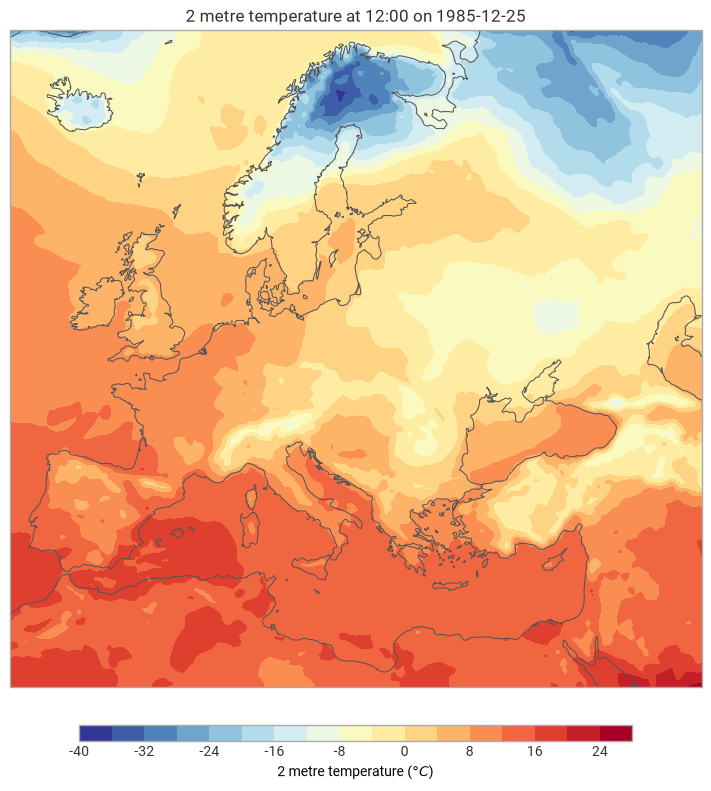

In [3]:
chart = ekp.Map(domain="Europe")
chart.contourf(
    temperature,
    units="celsius",
    levels={"step": 4, "reference": 0},
    colors="RdYlBu_r",
)
chart.legend()
chart.land()
chart.coastlines()
chart.title()
chart.show()

### The `extend` argument

By default, data values that fall outside the range of the specified
levels are not coloured — they appear as the background colour of the
map.  The `extend` argument controls whether the colourbar and the filled
regions are extended to cover out-of-range values:

- `extend="neither"` *(default)* — no extension; values outside the
  level range are uncoloured.
- `extend="min"` — add a triangle at the low end of the colourbar to
  capture values below the lowest level.
- `extend="max"` — add a triangle at the high end for values above the
  highest level.
- `extend="both"` — add triangles at both ends.

Here we restrict the levels to a narrow range (−10 to 20 °C) so that
some data falls outside at both ends, then compare the four options:

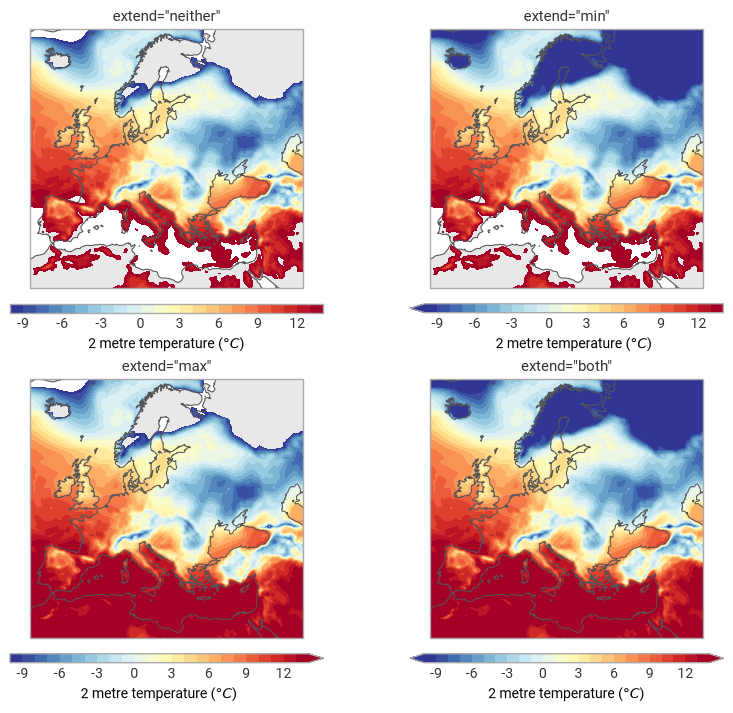

In [4]:
fig = ekp.Figure(domain="Europe", rows=2, columns=2)

for ext in ["neither", "min", "max", "both"]:
    chart = fig.add_map()
    chart.contourf(
        temperature,
        units="celsius",
        levels=range(-10, 15),
        colors="RdYlBu_r",
        extend=ext,
    )
    chart.legend()
    chart.land()
    chart.coastlines()
    chart.title(f'extend="{ext}"')
fig.show()

When using a reusable `Style` object, pass `extend` alongside the other
style options:

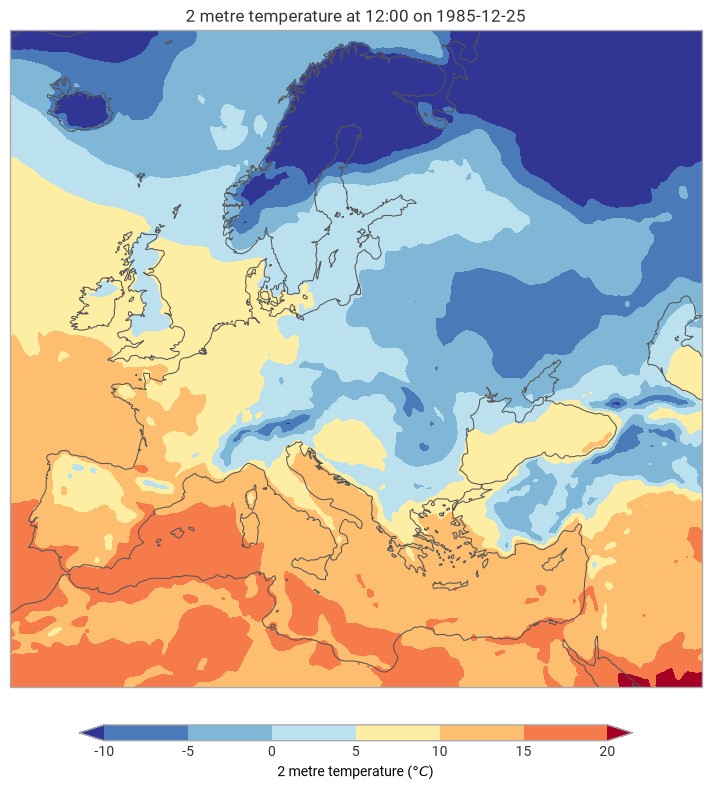

In [5]:
t2m_style_extended = ekp.styles.Style(
    units="celsius",
    colors="RdYlBu_r",
    levels=range(-10, 21, 5),
    extend="both",
)

chart = ekp.Map(domain="Europe")
chart.contourf(temperature, style=t2m_style_extended)
chart.legend()
chart.land()
chart.coastlines()
chart.title()
chart.show()

### Creating a reusable `Style`

Encapsulate all styling options in an `ekp.styles.Style` object so you
can apply the same look to multiple maps without repeating yourself.

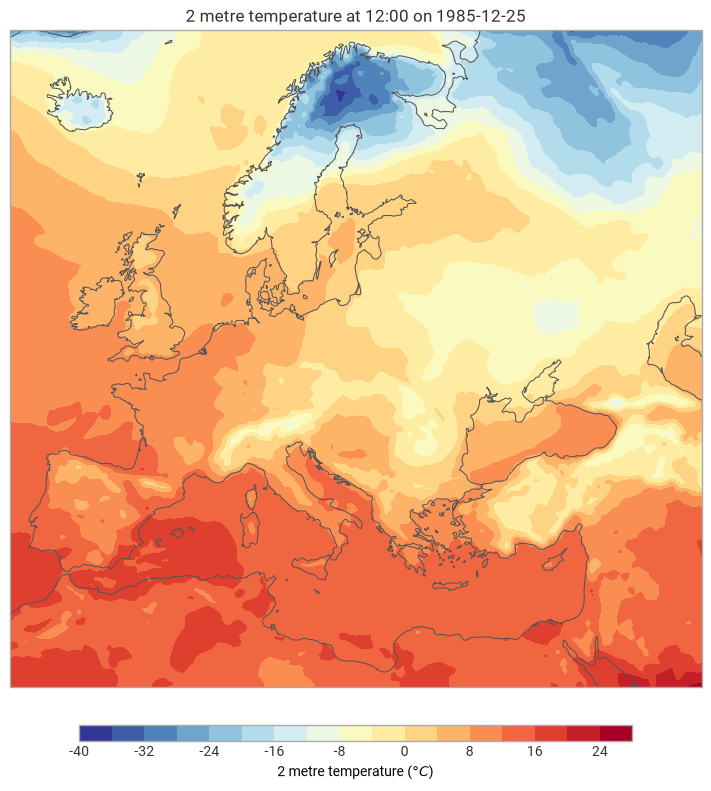

In [6]:
t2m_style = ekp.styles.Style(
    units="celsius",
    colors="RdYlBu_r",
    levels={"step": 4, "reference": 0},
)

chart = ekp.Map(domain="Europe")
chart.contourf(temperature, style=t2m_style)
chart.legend()
chart.land()
chart.coastlines()
chart.title()
chart.show()

### Reusing the style on a different domain

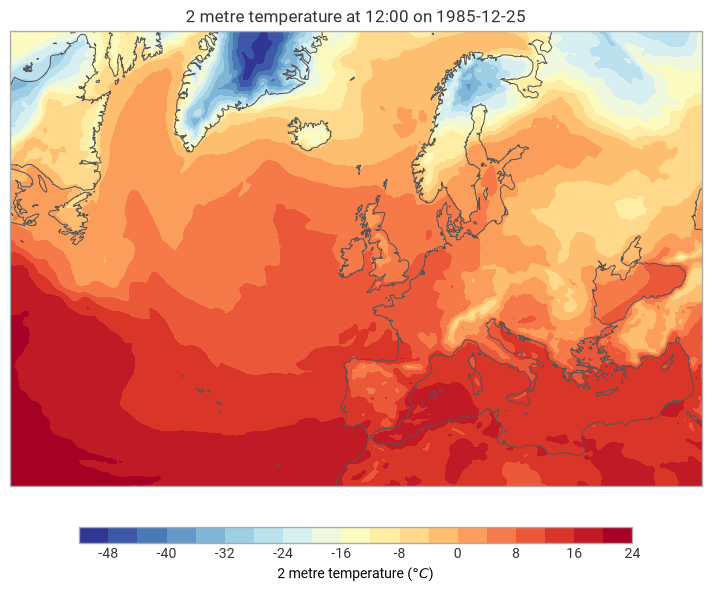

In [7]:
chart = ekp.Map(domain="North Atlantic")
chart.contourf(temperature, style=t2m_style)
chart.legend()
chart.land()
chart.coastlines()
chart.title()
chart.show()

### What's next?

The next notebook shows how to combine filled contours with contour lines
to highlight specific levels.